# investalyze — price-segment explorer

Chop selected price series into fixed-width raw windows via `investalyze.analysis.segments`, then
encode them and split into segment / successor downstream with `investalyze.analysis.encodings`.
This notebook drives the modules and sanity-checks the output — clustering and the next-segment
(transition) analysis come later.

Change `CLASSES` / `TICKERS` / `SEGMENT_LENGTH` / `SUCCESSOR_LENGTH` / `STRIDE` and re-run.

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np

from helpers import connect_readonly
from investalyze.analysis import encodings, segments

con = connect_readonly()

## Selection

Pick broadly by class (`stocks`, `indices`, `bonds`, `currencies`) and/or finely by ticker.

In [2]:
CLASSES = ['stocks', 'indices']
TICKERS = ['AAPL', 'MSFT', '^DJI', '^NDX']  # set to None for every ticker in the chosen classes

CLASSES = ['indices']
TICKERS = None
SEGMENT_LENGTH = 20             # trading rows per segment (the downstream split point)
SUCCESSOR_LENGTH = 5            # trading rows in the successor block
WINDOW_LENGTH = SEGMENT_LENGTH + SUCCESSOR_LENGTH
STRIDE = 20                     # step between window starts (== SEGMENT_LENGTH -> non-overlapping segments)

series = segments.load_series(con, classes=CLASSES, tickers=TICKERS)
series.groupby(['AssetClass', 'Ticker']).size()

AssetClass  Ticker
indices     ^AEX      11054
            ^AOR      13046
            ^ATH       9779
            ^BEL20     9003
            ^BET       6378
                      ...  
            ^TOP40     7788
            ^TSX      12621
            ^TWSE      7823
            ^UKX      23118
            ^XU100     9110
Length: 62, dtype: int64

## Build raw windows

In [3]:
W, meta = segments.build_segments(series, window_length=WINDOW_LENGTH, stride=STRIDE)
print('W       ', W.shape, '(raw prices)')
print('windows ', len(meta))
meta.head()

W        (31687, 25) (raw prices)
windows  31687


,segment_id,Ticker,AssetClass,start_date,end_date,start_idx
0,0,^AEX,indices,1983-01-03,1983-02-04,0
1,1,^AEX,indices,1983-01-31,1983-03-04,20
2,2,^AEX,indices,1983-02-28,1983-04-05,40
3,3,^AEX,indices,1983-03-28,1983-05-03,60
4,4,^AEX,indices,1983-04-27,1983-06-03,80


## Encode + split

`build_segments` returns **raw** prices. Pick an encoding from `investalyze.analysis.encodings`,
then split each row at `SEGMENT_LENGTH` into segment / successor.

- `rebase_to_100(W)` — width `WINDOW_LENGTH`; split at `SEGMENT_LENGTH`.
- `log_returns(W)` — width `WINDOW_LENGTH - 1`; segment returns `[:SEGMENT_LENGTH-1]`, the bridge
  (segment-end → successor-start) return at index `SEGMENT_LENGTH-1`, successor returns `[SEGMENT_LENGTH:]`.

In [4]:
R = encodings.rebase_to_100(W)
seg, succ = R[:, :SEGMENT_LENGTH], R[:, SEGMENT_LENGTH:]
print('seg ', seg.shape, ' succ', succ.shape)

seg  (31687, 20)  succ (31687, 5)


## Sanity plot — a few rebased segments

Every segment must start at 100; shapes overlay regardless of original price level.

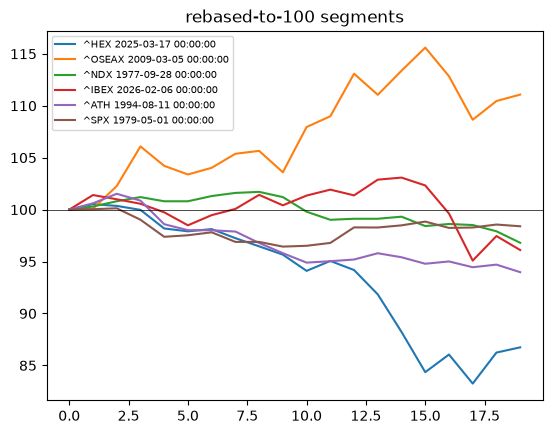

In [5]:
rng = np.random.default_rng(0)
sample = rng.choice(len(seg), size=min(6, len(seg)), replace=False)
for i in sample:
    plt.plot(seg[i], label=f"{meta.loc[i, 'Ticker']} {meta.loc[i, 'start_date']}")
plt.axhline(100, color='k', lw=0.5)
plt.title('rebased-to-100 segments')
plt.legend(fontsize=7)
plt.show()

## Successor example

The successor is the tail of each window — rows `[SEGMENT_LENGTH:]`, the contiguous block the
transition layer will study. `meta` carries the whole window span; `start_idx + Ticker` recovers
the exact rows from `series` if finer dates are needed.

In [6]:
s = 0  # first window
print('window  ', meta.loc[s, ['Ticker', 'start_date', 'end_date', 'start_idx']].to_dict())
print('segment ', seg[s].round(1))
print('successor', succ[s].round(1))

window   {'Ticker': '^AEX', 'start_date': Timestamp('1983-01-03 00:00:00'), 'end_date': Timestamp('1983-02-04 00:00:00'), 'start_idx': 0}
segment  [100.   99.5 103.  104.1 105.6 106.9 107.2 106.5 107.2 105.6 105.9 104.2
 104.  104.4 105.  101.5 103.1 104.2 103.3 106.2]
successor [106.6 105.9 104.7 105.4 105.4]
